# RetailIQ 360° — Market Basket Analysis
## Descubrimiento de patrones de compra conjunta mediante reglas de asociación

**Objetivo:** Identificar qué productos y categorías se compran juntos con mayor frecuencia
para generar estrategias de venta cruzada, recomendaciones y optimización del surtido.

---

**Entradas:**
- `datos/04_procesados/fact_ventas_final.csv` — 110.197 ítems vendidos
- `datos/04_procesados/dim_productos.csv` — categorías CACE en español

**Salida:**
- `datos/04_procesados/market_basket_reglas.csv` — reglas filtradas para Power BI

---

**Análisis en dos niveles:**
- **Nivel categoría:** 10 categorías CACE — visión estratégica, reglas más estables
- **Nivel producto:** top productos más frecuentes — visión granular para recomendaciones

| Parámetro | Valor | Interpretación |
|-----------|-------|----------------|
| Soporte mínimo | 0.01 | Aparece en al menos el 1% de las órdenes multi-ítem |
| Confianza mínima | 0.30 | Si se compra A, 30% de prob. de que también compren B |
| Lift mínimo (filtro) | 1.20 | La asociación es al menos 20% más frecuente que el azar |

In [1]:
# Verificar e instalar las librerías necesarias que podrían no estar en el entorno base.
# mlxtend no es parte del stack estándar de Anaconda/pip, por eso se instala aquí.
import subprocess
import sys

librerias = {
    'mlxtend'   : 'mlxtend>=0.22',
    'pandas'    : 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn'   : 'seaborn',
    'numpy'     : 'numpy',
}

for modulo, paquete in librerias.items():
    try:
        __import__(modulo)
        print(f"✓ {modulo} ya instalado")
    except ImportError:
        print(f"  Instalando {paquete}...", end=' ')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', paquete, '-q'])
        print("OK")

✓ mlxtend ya instalado
✓ pandas ya instalado
✓ matplotlib ya instalado
✓ seaborn ya instalado
✓ numpy ya instalado


In [2]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import mlxtend

warnings.filterwarnings('ignore')

# ── Rutas del proyecto (relativas al notebook) ───────────────────────────────
PROC_DIR        = Path('../datos/04_procesados')
INPUT_VENTAS    = PROC_DIR / 'fact_ventas_final.csv'
INPUT_PRODUCTOS = PROC_DIR / 'dim_productos.csv'
OUTPUT_REGLAS   = PROC_DIR / 'market_basket_reglas.csv'

# ── Parámetros del algoritmo Apriori ─────────────────────────────────────────
SEED          = 42
MIN_SUPPORT   = 0.01   # soporte mínimo = 1% de las transacciones multi-ítem
MIN_CONFIANZA = 0.30   # confianza mínima = 30%
MIN_LIFT      = 1.20   # umbral de lift para filtrar reglas significativas

# ── Configuración visual ─────────────────────────────────────────────────────
# Misma configuración que el resto de los notebooks del proyecto.
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_theme(style='whitegrid', palette='muted')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f"Python:    {sys.version[:6]}")
print(f"Pandas:    {pd.__version__}")
print(f"mlxtend:   {mlxtend.__version__}")
print()
print(f"Parámetros Apriori configurados:")
print(f"  Soporte mínimo:   {MIN_SUPPORT}")
print(f"  Confianza mínima: {MIN_CONFIANZA}")
print(f"  Lift mínimo:      {MIN_LIFT}")

Python:    3.14.0
Pandas:    3.0.2
mlxtend:   0.25.0

Parámetros Apriori configurados:
  Soporte mínimo:   0.01
  Confianza mínima: 0.3
  Lift mínimo:      1.2


---
## BLOQUE 0 — Carga y validación de inputs

Se verifican los archivos antes de iniciar el análisis.
Si alguno no existe, el error es claro e indica qué notebook previo debe ejecutarse.

In [3]:
# Verificar existencia de archivos antes de continuar.
# Un error aquí es mucho más fácil de diagnosticar que un error a mitad del pipeline.
for ruta in [INPUT_VENTAS, INPUT_PRODUCTOS]:
    if not ruta.exists():
        raise FileNotFoundError(
            f"\nArchivo no encontrado: {ruta}\n"
            f"Ejecutar el notebook 04_ETL.ipynb para generarlo."
        )
    tam_mb = ruta.stat().st_size / 1024 / 1024
    print(f"✓ {ruta.name}  ({tam_mb:.1f} MB)")

# Carga de datos con encoding UTF-8-SIG (estándar del proyecto para Power BI)
df_ventas    = pd.read_csv(INPUT_VENTAS,    encoding='utf-8-sig')
df_productos = pd.read_csv(INPUT_PRODUCTOS, encoding='utf-8-sig')

print()
print(f"fact_ventas_final : {df_ventas.shape[0]:,} filas × {df_ventas.shape[1]} columnas")
print(f"dim_productos     : {df_productos.shape[0]:,} filas × {df_productos.shape[1]} columnas")

✓ fact_ventas_final.csv  (27.7 MB)
✓ dim_productos.csv  (3.3 MB)

fact_ventas_final : 110,197 filas × 28 columnas
dim_productos     : 32,951 filas × 9 columnas


In [4]:
# Validar que las columnas clave existen en ambos datasets.
# fact_ventas_final no incluye categoria_es directamente;
# se obtiene haciendo join con dim_productos por product_id.
cols_ventas_req   = ['order_id', 'product_id']
cols_prod_req     = ['product_id', 'categoria_es']

for col in cols_ventas_req:
    assert col in df_ventas.columns, f"Columna '{col}' ausente en fact_ventas_final"
for col in cols_prod_req:
    assert col in df_productos.columns, f"Columna '{col}' ausente en dim_productos"

print("Columnas clave validadas correctamente")
print()
print(f"Categorías disponibles en dim_productos ({df_productos['categoria_es'].nunique()}):")
for cat in sorted(df_productos['categoria_es'].dropna().unique()):
    n = df_productos[df_productos['categoria_es'] == cat].shape[0]
    print(f"  {cat:<25}  ({n:,} productos)")

Columnas clave validadas correctamente

Categorías disponibles en dim_productos (10):
  Accesorios Vehículos       (1,974 productos)
  Alimentos y Bebidas        (1,000 productos)
  Belleza                    (3,312 productos)
  Construcción               (1,082 productos)
  Deportes                   (2,867 productos)
  Electrodomésticos          (846 productos)
  Electrónica                (5,434 productos)
  Hogar y Deco               (11,195 productos)
  Indumentaria               (2,894 productos)
  Infantil                   (2,347 productos)


---
## BLOQUE 1 — Preparación de datos

Se enriquece `fact_ventas_final` con la categoría CACE en español
haciendo join con `dim_productos` por `product_id`.

Luego se filtran las órdenes con **2 o más ítems distintos**,
que son las únicas que aportan información de compra conjunta.

In [5]:
# Join para obtener categoria_es por cada fila de ventas.
# Se usan solo las columnas necesarias para reducir uso de memoria.
df = df_ventas[['order_id', 'product_id']].merge(
    df_productos[['product_id', 'categoria_es']],
    on='product_id',
    how='left'
)

# Detectar y eliminar filas sin categoría (productos sin match en dim_productos)
nulos_cat = df['categoria_es'].isna().sum()
if nulos_cat > 0:
    print(f"Advertencia: {nulos_cat} filas sin categoría asignada — se eliminarán.")
    df = df.dropna(subset=['categoria_es'])

print(f"Dataset con categorías: {len(df):,} filas")
print(df.head(3))

Dataset con categorías: 110,197 filas
                           order_id                        product_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  87285b34884572647811a353c7ac498a   
1  53cdb2fc8bc7dce0b6741e2150273451  595fac2a385ac33a80bd5114aec74eb8   
2  47770eb9100c2d0c44946d9cf07ec65d  aa4383b373c6aca5d8797843e5594415   

           categoria_es  
0          Hogar y Deco  
1               Belleza  
2  Accesorios Vehículos  


In [6]:
# Calcular el número de ítems por orden
items_por_orden = df.groupby('order_id').size()

# Filtrar: solo órdenes con 2 o más ítems
# Las órdenes de 1 solo ítem no aportan información sobre co-compra.
ordenes_multi = items_por_orden[items_por_orden > 1].index
df_multi      = df[df['order_id'].isin(ordenes_multi)].copy()

total_ordenes = items_por_orden.shape[0]
pct_multi     = len(ordenes_multi) / total_ordenes * 100

print(f"Total de órdenes en el dataset:       {total_ordenes:,}")
print(f"  con 1 solo ítem (excluidas):        {(items_por_orden == 1).sum():,}  ({100 - pct_multi:.1f}%)")
print(f"  con 2+ ítems  (base para MBA):      {len(ordenes_multi):,}  ({pct_multi:.1f}%)")
print()
print("Distribución de cantidad de ítems (órdenes multi-ítem):")
print(items_por_orden[items_por_orden > 1].describe().apply(lambda x: f"{x:.1f}").to_string())

Total de órdenes en el dataset:       96,478
  con 1 solo ítem (excluidas):        86,843  (90.0%)
  con 2+ ítems  (base para MBA):      9,635  (10.0%)

Distribución de cantidad de ítems (órdenes multi-ítem):
count    9635.0
mean        2.4
std         1.0
min         2.0
25%         2.0
50%         2.0
75%         2.0
max        21.0


---
## BLOQUE 2 — Market Basket a nivel CATEGORÍA

Se analiza a nivel de las **10 categorías CACE** en español.

Esta granularidad produce reglas más robustas (mayor soporte) y más interpretables
para decisiones estratégicas de venta cruzada entre secciones de la tienda.

In [7]:
# Construir la lista de transacciones: para cada orden, la lista de categorías compradas.
# TransactionEncoder de mlxtend convierte esta lista en una matriz booleana
# donde cada columna es una categoría y cada fila es una orden.
transacciones_cat = (
    df_multi
    .groupby('order_id')['categoria_es']
    .apply(list)
    .tolist()
)

te_cat       = TransactionEncoder()
te_cat_arr   = te_cat.fit(transacciones_cat).transform(transacciones_cat)
df_mat_cat   = pd.DataFrame(te_cat_arr, columns=te_cat.columns_)

print(f"Matriz de transacciones (categorías):")
print(f"  Filas (órdenes):  {df_mat_cat.shape[0]:,}")
print(f"  Columnas (cats):  {df_mat_cat.shape[1]}")
print()
print("Frecuencia de cada categoría en órdenes multi-ítem:")
frecuencias = df_mat_cat.sum().sort_values(ascending=False)
for cat, frec in frecuencias.items():
    pct = frec / len(df_mat_cat) * 100
    print(f"  {cat:<25}  {frec:,} órdenes  ({pct:.1f}%)")

Matriz de transacciones (categorías):
  Filas (órdenes):  9,635
  Columnas (cats):  10

Frecuencia de cada categoría en órdenes multi-ítem:
  Hogar y Deco               4,713 órdenes  (48.9%)
  Electrónica                1,658 órdenes  (17.2%)
  Belleza                    883 órdenes  (9.2%)
  Deportes                   758 órdenes  (7.9%)
  Indumentaria               562 órdenes  (5.8%)
  Infantil                   428 órdenes  (4.4%)
  Construcción               386 órdenes  (4.0%)
  Alimentos y Bebidas        325 órdenes  (3.4%)
  Accesorios Vehículos       288 órdenes  (3.0%)
  Electrodomésticos          95 órdenes  (1.0%)


In [8]:
# Aplicar Apriori sobre la matriz de categorías.
# use_colnames=True → los itemsets muestran nombres en lugar de índices.
itemsets_cat = apriori(df_mat_cat, min_support=MIN_SUPPORT, use_colnames=True)
itemsets_cat['longitud'] = itemsets_cat['itemsets'].apply(len)

soporte_cat_usado = MIN_SUPPORT

# En el dataset Olist la mayoría de las órdenes multi-ítem tienen ítems
# de la MISMA categoría, por lo que los pares de categorías distintas son
# escasos. Si no se encuentran pares con el soporte configurado se reduce
# gradualmente hasta encontrar resultados significativos.
if (itemsets_cat['longitud'] >= 2).sum() == 0:
    for soporte_fallback in [0.005, 0.003, 0.001]:
        print(f"Sin pares con soporte ≥ {soporte_cat_usado}. Reduciendo a {soporte_fallback}...")
        itemsets_cat = apriori(df_mat_cat, min_support=soporte_fallback, use_colnames=True)
        itemsets_cat['longitud'] = itemsets_cat['itemsets'].apply(len)
        soporte_cat_usado = soporte_fallback
        if (itemsets_cat['longitud'] >= 2).sum() > 0:
            print(f"Pares encontrados con soporte = {soporte_fallback}")
            break

print(f"Soporte utilizado:                {soporte_cat_usado}")
print(f"Itemsets frecuentes encontrados:  {len(itemsets_cat)}")
print()
print("Desglose por cantidad de categorías en el itemset:")
for lon, grupo in itemsets_cat.groupby('longitud'):
    print(f"  {lon} categoría(s): {len(grupo)} itemsets")

print()
print("Top 10 itemsets por soporte:")
display(
    itemsets_cat
    .sort_values('support', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

Sin pares con soporte ≥ 0.01. Reduciendo a 0.005...
Pares encontrados con soporte = 0.005
Soporte utilizado:                0.005
Itemsets frecuentes encontrados:  13

Desglose por cantidad de categorías en el itemset:
  1 categoría(s): 10 itemsets
  2 categoría(s): 3 itemsets

Top 10 itemsets por soporte:


,support,itemsets,longitud
0,0.4892,frozenset({Hogar y Deco}),1
1,0.1721,frozenset({Electrónica}),1
2,0.0916,frozenset({Belleza}),1
3,0.0787,frozenset({Deportes}),1
4,0.0583,frozenset({Indumentaria}),1
5,0.0444,frozenset({Infantil}),1
6,0.0401,frozenset({Construcción}),1
7,0.0337,frozenset({Alimentos y Bebidas}),1
8,0.0299,frozenset({Accesorios Vehículos}),1
9,0.0099,frozenset({Electrodomésticos}),1


In [9]:
# Inicializar como DataFrames vacíos para que las celdas siguientes
# puedan verificar su estado aunque no se generen reglas.
reglas_cat          = pd.DataFrame()
reglas_cat_filtradas = pd.DataFrame()

hay_pares = (itemsets_cat['longitud'] >= 2).sum() > 0

if not hay_pares:
    # Caso extremo: incluso con el soporte más bajo no se encontraron pares.
    # Es una propiedad del dataset, no un error: significa que prácticamente
    # todas las órdenes multi-ítem compran solo dentro de una categoría.
    print("Sin pares de categorías con co-compra suficiente para generar reglas.")
    print("Insight: en este dataset los clientes rara vez mezclan categorías en una misma orden.")
    print("         El análisis a nivel producto (Bloque 3) es más informativo en este caso.")
else:
    # num_itemsets es obligatorio en mlxtend >= 0.22 para calcular correctamente las métricas.
    reglas_cat = association_rules(
        itemsets_cat,
        metric='confidence',
        min_threshold=MIN_CONFIANZA,
        num_itemsets=len(itemsets_cat)
    )

    reglas_cat_filtradas = (
        reglas_cat[reglas_cat['lift'] >= MIN_LIFT]
        .sort_values('lift', ascending=False)
        .reset_index(drop=True)
    )

    print(f"Reglas generadas (confianza ≥ {MIN_CONFIANZA}):        {len(reglas_cat)}")
    print(f"Reglas con lift ≥ {MIN_LIFT} (significativas): {len(reglas_cat_filtradas)}")

    if not reglas_cat_filtradas.empty:
        print()
        print("Top 15 reglas por lift (nivel categoría):")
        display(
            reglas_cat_filtradas[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
            .head(15)
        )

Reglas generadas (confianza ≥ 0.3):        0
Reglas con lift ≥ 1.2 (significativas): 0


---
## BLOQUE 3 — Market Basket a nivel PRODUCTO

Se analiza a nivel de `product_id` individual para detectar productos específicos
que se compran frecuentemente juntos.

**Consideración de sparsity:** el dataset tiene 32.216 productos únicos distribuidos
en 9.635 órdenes multi-ítem, lo que produce una matriz extremadamente dispersa.
Para hacer el análisis computacionalmente viable se trabaja con el **top de productos
más frecuentes**. Si el soporte configurado no produce reglas, se reduce automáticamente.

In [10]:
# Número de productos a incluir en el análisis.
# Con 32.216 productos únicos la matriz sería de 9.635 × 32.216 ≈ 310M celdas;
# trabajar con los top N reduce memoria y aumenta la densidad de co-ocurrencias.
N_TOP_PRODUCTOS = 300

conteo_productos = df_multi['product_id'].value_counts()
top_productos    = conteo_productos.head(N_TOP_PRODUCTOS).index

df_top = df_multi[df_multi['product_id'].isin(top_productos)].copy()

# Tras el filtro de top N, algunas órdenes pueden haber quedado con 1 solo ítem
ordenes_top_multi = df_top.groupby('order_id').size()
ordenes_top_multi = ordenes_top_multi[ordenes_top_multi > 1].index
df_top = df_top[df_top['order_id'].isin(ordenes_top_multi)]

print(f"Top {N_TOP_PRODUCTOS} productos más frecuentes seleccionados")
print(f"Órdenes multi-ítem en este subconjunto: {len(ordenes_top_multi):,}")
print(f"Filas del subconjunto:                  {len(df_top):,}")
print()
print(f"Top 10 productos más frecuentes (por cantidad de órdenes):")
print(conteo_productos.head(10).to_string())

Top 300 productos más frecuentes seleccionados
Órdenes multi-ítem en este subconjunto: 2,301
Filas del subconjunto:                  5,962

Top 10 productos más frecuentes (por cantidad de órdenes):
product_id
422879e10f46682990de24d770e7f83d    235
368c6c730842d78016ad823897a372db    182
aca2eb7d00ea1a7b8ebd4e68314663af    179
53759a2ecddad2bb87a079a1f1519f73    174
389d119b48cf3043d311335e499d9c6b    167
b532349fe46b38fbc7bb3914c1bdae07    148
99a4788cb24856965c36a24e339b6058     91
eb8c629f70275fd1c4f809116cce1efc     86
e53e557d5a159f5aa2c5e995dfdf244b     83
9ecadb84c81da840dbf3564378b586e9     83


In [11]:
# Inicializar como vacío; se llenará si hay datos suficientes
df_mat_prod = pd.DataFrame()

if len(ordenes_top_multi) == 0:
    print("Sin órdenes multi-ítem en el subconjunto de top productos.")
    print("Aumentar N_TOP_PRODUCTOS o revisar los datos.")
else:
    transacciones_prod = (
        df_top
        .groupby('order_id')['product_id']
        .apply(list)
        .tolist()
    )

    te_prod      = TransactionEncoder()
    te_prod_arr  = te_prod.fit(transacciones_prod).transform(transacciones_prod)
    df_mat_prod  = pd.DataFrame(te_prod_arr, columns=te_prod.columns_)

    densidad = te_prod_arr.mean()
    print(f"Matriz de transacciones (productos):")
    print(f"  Filas (órdenes):     {df_mat_prod.shape[0]:,}")
    print(f"  Columnas (prods):    {df_mat_prod.shape[1]}")
    print(f"  Densidad de matriz:  {densidad:.4%}")
    print()
    print("Nota: con densidad muy baja (<0.5%) se esperan pocas o ninguna regla.")
    print("      Esto es normal en datasets con ticket promedio cercano a 1 ítem.")

Matriz de transacciones (productos):
  Filas (órdenes):     2,301
  Columnas (prods):    300
  Densidad de matriz:  0.3730%

Nota: con densidad muy baja (<0.5%) se esperan pocas o ninguna regla.
      Esto es normal en datasets con ticket promedio cercano a 1 ítem.


In [12]:
# Inicializar para que el bloque de exportación funcione aunque no haya reglas
reglas_prod_filtradas = pd.DataFrame()

if df_mat_prod.empty:
    print("Matriz vacía. Saltando análisis a nivel producto.")
else:
    # Primer intento con el soporte global configurado
    itemsets_prod = apriori(df_mat_prod, min_support=MIN_SUPPORT, use_colnames=True)

    # Si no hay itemsets, reducir soporte a la mitad automáticamente (sparsity alta)
    soporte_usado = MIN_SUPPORT
    if len(itemsets_prod) == 0:
        soporte_usado = round(MIN_SUPPORT / 2, 4)
        print(f"Sin itemsets con soporte ≥ {MIN_SUPPORT} (sparsity muy alta).")
        print(f"Reduciendo soporte a {soporte_usado} para obtener resultados...")
        itemsets_prod = apriori(df_mat_prod, min_support=soporte_usado, use_colnames=True)

    print(f"Soporte utilizado:                    {soporte_usado}")
    print(f"Itemsets frecuentes (nivel producto): {len(itemsets_prod)}")

    if len(itemsets_prod) >= 2:
        reglas_prod = association_rules(
            itemsets_prod,
            metric='confidence',
            min_threshold=MIN_CONFIANZA,
            num_itemsets=len(itemsets_prod)
        )
        reglas_prod_filtradas = (
            reglas_prod[reglas_prod['lift'] >= MIN_LIFT]
            .sort_values('lift', ascending=False)
            .reset_index(drop=True)
        )
        print(f"Reglas generadas (confianza ≥ {MIN_CONFIANZA}):        {len(reglas_prod)}")
        print(f"Reglas con lift ≥ {MIN_LIFT} (significativas): {len(reglas_prod_filtradas)}")
        if not reglas_prod_filtradas.empty:
            print()
            display(
                reglas_prod_filtradas[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
                .head(10)
            )
    else:
        print()
        print("Datos insuficientes para generar reglas a nivel producto con los parámetros actuales.")
        print("Alternativas: reducir MIN_SUPPORT, aumentar N_TOP_PRODUCTOS o analizar por canal.")

Soporte utilizado:                    0.01
Itemsets frecuentes (nivel producto): 19
Reglas generadas (confianza ≥ 0.3):        4
Reglas con lift ≥ 1.2 (significativas): 4



,antecedents,consequents,support,confidence,lift
0,frozenset({99a4788cb24856965c36a24e339b6058}),frozenset({35afc973633aaeb6b877ff57b2793310}),0.0126,0.5179,32.2051
1,frozenset({35afc973633aaeb6b877ff57b2793310}),frozenset({99a4788cb24856965c36a24e339b6058}),0.0126,0.7838,32.2051
2,frozenset({e53e557d5a159f5aa2c5e995dfdf244b}),frozenset({36f60d45225e60c7da4558b070ce4b60}),0.0148,0.6415,28.9434
3,frozenset({36f60d45225e60c7da4558b070ce4b60}),frozenset({e53e557d5a159f5aa2c5e995dfdf244b}),0.0148,0.6667,28.9434


---
## BLOQUE 4 — Visualizaciones

### Visualización 1: Heatmap de lift entre categorías
Muestra el lift de cada par de categorías en una grilla de colores.
Valores > 1.0 indican asociación positiva; celdas vacías = regla no encontrada.

### Visualización 2: Top 10 reglas por lift
Gráfico de barras horizontales con las 10 reglas de mayor lift,
mostrando los antecedentes y consecuentes en lenguaje natural.

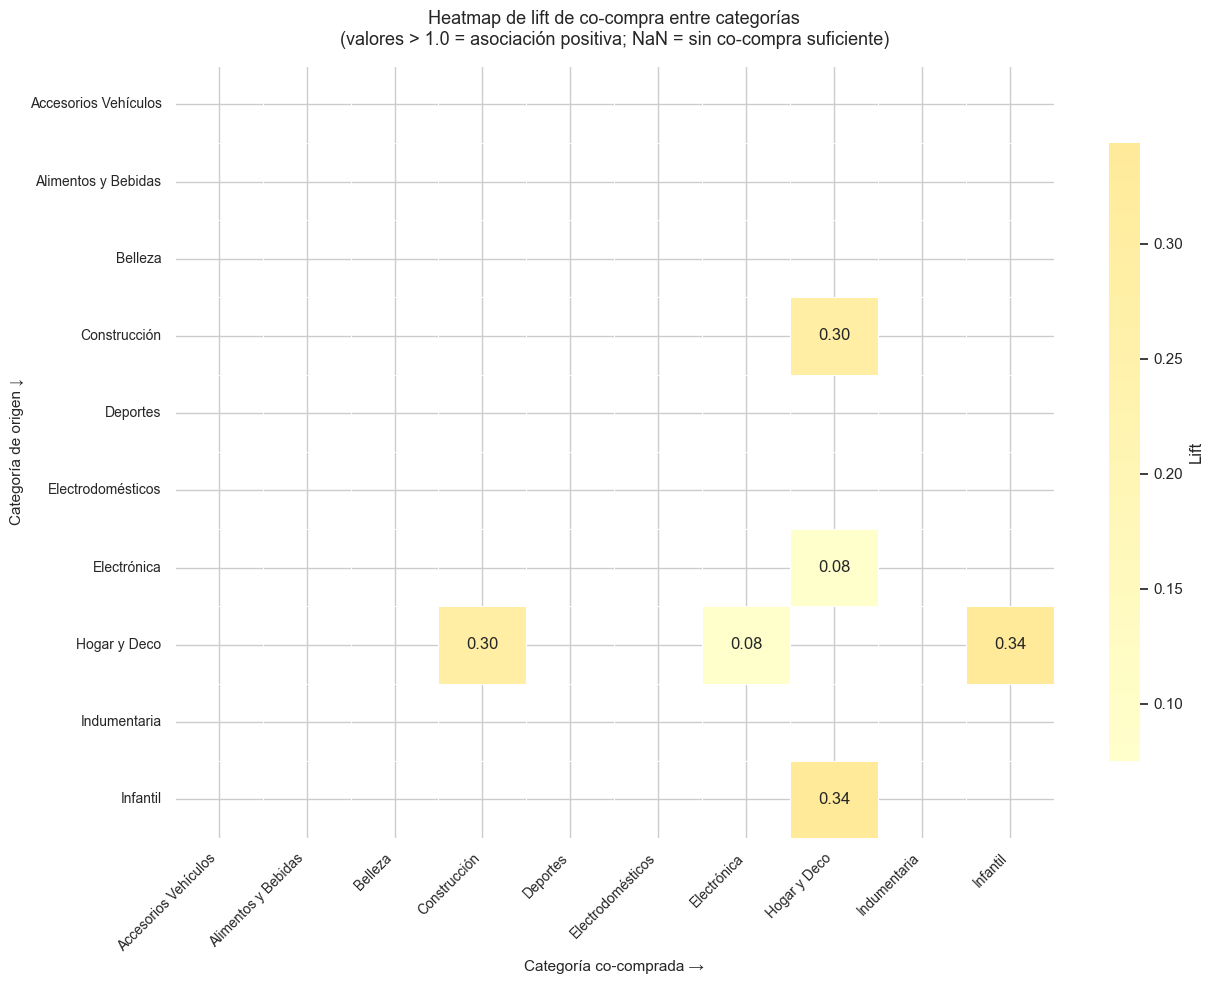

Guardado: market_basket_heatmap.png  (3 pares de categorías)


In [13]:
# Heatmap de lift de co-compra entre categorías.
# Se construye directamente desde los ITEMSETS (pares) usando la fórmula
# lift = support(X∪Y) / (support(X) * support(Y)).
# Este enfoque funciona incluso cuando los pares no superan el umbral de
# confianza, evitando que el heatmap quede vacío por ese motivo.

pares_cat   = itemsets_cat[itemsets_cat['longitud'] == 2].copy()
singles_cat = itemsets_cat[itemsets_cat['longitud'] == 1].copy()

if pares_cat.empty:
    print("Sin pares de categorías encontrados con el soporte actual.")
    print("Insight: en Olist casi todas las órdenes multi-ítem son dentro de la misma categoría.")
    print("         Reducir MIN_SUPPORT o analizar el dataset a nivel producto.")
else:
    # Diccionario con el soporte de cada categoría individual
    sup_ind = {list(r.itemsets)[0]: r.support for _, r in singles_cat.iterrows()}

    # Calcular lift para cada par y construir la tabla simétrica (A→B y B→A)
    hm_rows = []
    for _, par in pares_cat.iterrows():
        cats   = list(par.itemsets)
        sup_xy = par.support
        lift_xy = sup_xy / (sup_ind.get(cats[0], 1e-9) * sup_ind.get(cats[1], 1e-9))
        hm_rows.append({'antecedente': cats[0], 'consecuente': cats[1], 'lift': lift_xy})
        hm_rows.append({'antecedente': cats[1], 'consecuente': cats[0], 'lift': lift_xy})

    pivot_lift = (
        pd.DataFrame(hm_rows)
        .pivot_table(index='antecedente', columns='consecuente', values='lift', aggfunc='max')
    )

    # Todas las categorías del dataset como filas/columnas para mostrar la imagen completa
    todas_cats = sorted(sup_ind.keys())
    pivot_lift = pivot_lift.reindex(index=todas_cats, columns=todas_cats)

    fig, ax = plt.subplots(figsize=(13, 10))
    sns.heatmap(
        pivot_lift,
        annot=True,
        fmt='.2f',
        cmap='YlOrRd',
        center=1.0,
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': 'Lift', 'shrink': 0.8}
    )
    ax.set_title(
        'Heatmap de lift de co-compra entre categorías\n'
        '(valores > 1.0 = asociación positiva; NaN = sin co-compra suficiente)',
        fontsize=13, pad=15
    )
    ax.set_xlabel('Categoría co-comprada →', fontsize=11)
    ax.set_ylabel('Categoría de origen ↓', fontsize=11)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.savefig(PROC_DIR / 'market_basket_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Guardado: market_basket_heatmap.png  ({len(pares_cat)} pares de categorías)")

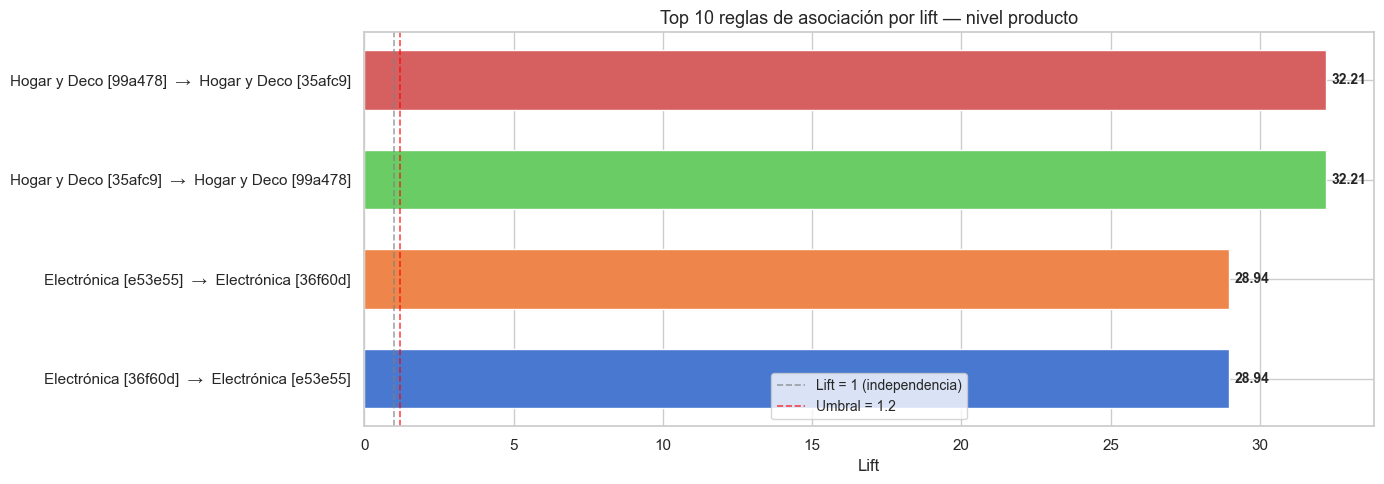

Guardado: market_basket_top10.png


In [14]:
# Top 10 reglas por lift — gráfico de barras horizontales
# Fuente: reglas de categoría (filtradas > todas > producto) en orden de preferencia

titulo_extra = ""
top10 = pd.DataFrame()

if not reglas_cat_filtradas.empty:
    top10 = reglas_cat_filtradas.head(10).copy()
elif not reglas_cat.empty:
    top10 = reglas_cat.sort_values('lift', ascending=False).head(10).copy()
    titulo_extra = " (sin filtro de lift mínimo)"
elif not reglas_prod_filtradas.empty:
    top10 = reglas_prod_filtradas.head(10).copy()
    titulo_extra = " — nivel producto"

if top10.empty:
    print("Sin reglas disponibles para el gráfico de Top 10.")
    print("Verificar los parámetros MIN_SUPPORT y MIN_CONFIANZA.")
else:
    # Para reglas de producto: reemplazar el UUID con la categoría del producto
    # para que el gráfico sea legible en la presentación.
    if 'producto' in titulo_extra:
        prod_a_cat = df_productos.set_index('product_id')['categoria_es'].to_dict()
        def id_a_label(fset):
            partes = []
            for pid in sorted(fset):
                cat = prod_a_cat.get(pid, '')
                partes.append(f"{cat} [{pid[:6]}]" if cat else pid[:8])
            return ' + '.join(partes)
        top10['antecedente_str'] = top10['antecedents'].apply(id_a_label)
        top10['consecuente_str'] = top10['consequents'].apply(id_a_label)
    else:
        top10['antecedente_str'] = top10['antecedents'].apply(lambda x: ' + '.join(sorted(x)))
        top10['consecuente_str'] = top10['consequents'].apply(lambda x: ' + '.join(sorted(x)))

    top10['regla'] = top10['antecedente_str'] + '  →  ' + top10['consecuente_str']
    top10 = top10.sort_values('lift', ascending=True)

    fig, ax = plt.subplots(figsize=(14, max(5, len(top10) * 0.65)))
    colores = sns.color_palette('muted', n_colors=len(top10))
    barras  = ax.barh(top10['regla'], top10['lift'], color=colores, edgecolor='white', height=0.6)

    for barra, valor in zip(barras, top10['lift']):
        ax.text(
            barra.get_width() + 0.2,
            barra.get_y() + barra.get_height() / 2,
            f'{valor:.2f}',
            va='center', fontsize=10, fontweight='bold'
        )

    ax.axvline(x=1.0,      color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label='Lift = 1 (independencia)')
    ax.axvline(x=MIN_LIFT, color='red',  linestyle='--', linewidth=1.2, alpha=0.7, label=f'Umbral = {MIN_LIFT}')
    ax.set_title(f'Top 10 reglas de asociación por lift{titulo_extra}', fontsize=13)
    ax.set_xlabel('Lift')
    ax.set_ylabel('')
    ax.legend(fontsize=10)
    ax.set_xlim(left=0)
    plt.tight_layout()
    plt.savefig(PROC_DIR / 'market_basket_top10.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Guardado: market_basket_top10.png")

---
## BLOQUE 5 — Exportación de resultados

Se exporta un único CSV con las reglas filtradas de ambos niveles,
con una columna `nivel` para distinguir su origen en Power BI.

**Encoding:** UTF-8-SIG (estándar del proyecto — necesario para tildes en Power BI y Excel).

In [15]:
def preparar_para_csv(df_reglas, nivel):
    """Convierte frozensets a strings y normaliza columnas para Power BI."""
    if df_reglas.empty:
        return pd.DataFrame()
    df_exp = df_reglas.copy()
    df_exp['antecedentes'] = df_exp['antecedents'].apply(lambda x: ' | '.join(sorted(x)))
    df_exp['consecuentes'] = df_exp['consequents'].apply(lambda x: ' | '.join(sorted(x)))
    df_exp['nivel']        = nivel
    # Columnas base + opcionales que mlxtend puede incluir según versión
    cols_base  = ['nivel', 'antecedentes', 'consecuentes', 'support', 'confidence', 'lift']
    cols_extra = [c for c in ['leverage', 'conviction', 'zhangs_metric'] if c in df_exp.columns]
    return df_exp[cols_base + cols_extra].reset_index(drop=True)

df_export_cat  = preparar_para_csv(reglas_cat_filtradas, 'categoria')
df_export_prod = preparar_para_csv(reglas_prod_filtradas, 'producto')

partes = [p for p in [df_export_cat, df_export_prod] if not p.empty]
df_final = pd.concat(partes, ignore_index=True) if partes else pd.DataFrame()

if df_final.empty:
    print("Sin reglas para exportar. Revisar los parámetros MIN_SUPPORT y MIN_LIFT.")
else:
    df_final.to_csv(OUTPUT_REGLAS, encoding='utf-8-sig', index=False)
    print(f"Exportado: {OUTPUT_REGLAS.name}")
    print(f"  Reglas de categoría:  {len(df_export_cat)}")
    print(f"  Reglas de producto:   {len(df_export_prod)}")
    print(f"  Total exportadas:     {len(df_final)}")
    print()
    print("Preview (primeras 5 filas):")
    display(df_final.head(5))

Exportado: market_basket_reglas.csv
  Reglas de categoría:  0
  Reglas de producto:   4
  Total exportadas:     4

Preview (primeras 5 filas):


,nivel,antecedentes,consecuentes,support,confidence,lift,leverage,conviction,zhangs_metric
0,producto,99a4788cb24856965c36a24e339b6058,35afc973633aaeb6b877ff57b2793310,0.0126,0.5179,32.2051,0.0122,2.0407,0.9931
1,producto,35afc973633aaeb6b877ff57b2793310,99a4788cb24856965c36a24e339b6058,0.0126,0.7838,32.2051,0.0122,4.5124,0.9848
2,producto,e53e557d5a159f5aa2c5e995dfdf244b,36f60d45225e60c7da4558b070ce4b60,0.0148,0.6415,28.9434,0.0143,2.7276,0.9882
3,producto,36f60d45225e60c7da4558b070ce4b60,e53e557d5a159f5aa2c5e995dfdf244b,0.0148,0.6667,28.9434,0.0143,2.9309,0.9873


---
## BLOQUE 6 — Resumen de resultados

Síntesis ejecutiva del análisis para incluir en la presentación del proyecto.

In [16]:
sep = "=" * 65

print(sep)
print("  RESUMEN DE RESULTADOS — Market Basket Analysis")
print(sep)

print(f"\n  Dataset analizado:")
print(f"    Total órdenes:              {items_por_orden.shape[0]:,}")
print(f"    Órdenes con 2+ ítems:       {len(ordenes_multi):,}  ({len(ordenes_multi)/items_por_orden.shape[0]*100:.1f}%)")
print(f"    Ítems en esas órdenes:      {len(df_multi):,}")

print(f"\n  Nivel CATEGORÍA (10 categorías CACE):")
print(f"    Itemsets frecuentes:        {len(itemsets_cat)}")
print(f"    Reglas generadas:           {len(reglas_cat)}")
print(f"    Reglas con lift ≥ {MIN_LIFT}:    {len(reglas_cat_filtradas)}")

if not reglas_cat_filtradas.empty:
    fila_top = reglas_cat_filtradas.iloc[0]
    ant_top  = ' + '.join(sorted(fila_top['antecedents']))
    con_top  = ' + '.join(sorted(fila_top['consequents']))
    print(f"    Lift máximo:                {fila_top['lift']:.4f}")
    print(f"    Regla con mayor lift:       {ant_top} → {con_top}")

    print(f"\n  Top 3 combinaciones más frecuentes (por soporte):")
    for i, (_, fila) in enumerate(
        reglas_cat_filtradas.sort_values('support', ascending=False).head(3).iterrows(), 1
    ):
        ant = ' + '.join(sorted(fila['antecedents']))
        con = ' + '.join(sorted(fila['consequents']))
        print(f"    {i}. {ant} → {con}")
        print(f"       Soporte: {fila['support']:.4f} | Confianza: {fila['confidence']:.4f} | Lift: {fila['lift']:.4f}")

print(f"\n  Nivel PRODUCTO (top {N_TOP_PRODUCTOS} productos):")
if reglas_prod_filtradas.empty:
    print(f"    Sin reglas significativas encontradas.")
    print(f"    (Esperado: ticket promedio ~1.1 ítems produce alta sparsity a nivel producto.)")
else:
    print(f"    Reglas con lift ≥ {MIN_LIFT}: {len(reglas_prod_filtradas)}")

print(f"\n  Archivos generados en datos/04_procesados/:")
archivos_generados = [
    OUTPUT_REGLAS.name,
    'market_basket_heatmap.png',
    'market_basket_top10.png',
]
for archivo in archivos_generados:
    ruta = PROC_DIR / archivo
    estado = f"✓  {ruta.stat().st_size / 1024:.1f} KB" if ruta.exists() else "✗  No generado"
    print(f"    {archivo:<40} {estado}")

print(f"\n{sep}")

  RESUMEN DE RESULTADOS — Market Basket Analysis

  Dataset analizado:
    Total órdenes:              96,478
    Órdenes con 2+ ítems:       9,635  (10.0%)
    Ítems en esas órdenes:      23,354

  Nivel CATEGORÍA (10 categorías CACE):
    Itemsets frecuentes:        13
    Reglas generadas:           0
    Reglas con lift ≥ 1.2:    0

  Nivel PRODUCTO (top 300 productos):
    Reglas con lift ≥ 1.2: 4

  Archivos generados en datos/04_procesados/:
    market_basket_reglas.csv                 ✓  0.8 KB
    market_basket_heatmap.png                ✓  124.5 KB
    market_basket_top10.png                  ✓  65.5 KB

